In [46]:
import sys
import os

sys.path.append(os.path.abspath(".."))
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from src. preprocess import preprocess_text
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,recall_score,f1_score,classification_report

In [2]:
data = pd.read_csv("../data/email.csv", encoding="utf-8")
df = pd.DataFrame(data)


In [3]:
print(df.head())
print(df.tail())

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
     Category                                            Message
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham               Will ü b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name


In [4]:
print(df.shape)
print(df.columns)
print(type(df))
df.info()

(5572, 2)
Index(['Category', 'Message'], dtype='str')
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [5]:
total_spam = df["Category"].value_counts()["spam"]
total_ham = df["Category"].value_counts()["ham"]
total_email =  len(df)
percentage_ham = (total_ham/total_email )*100
percentage_spam = (total_spam/total_email )*100
print(percentage_ham)
print(percentage_spam)

86.59368269921033
13.406317300789663


In [6]:
def plot_barchat(X_axis,y_axis):
    plt.bar(X_axis,y_axis,color='green',label='Spam or ham email',)
    plt.Figure(figsize=(8,5))
    plt.xlabel('Category')
    plt.ylabel('count')
    plt.title('Email spam detection')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()


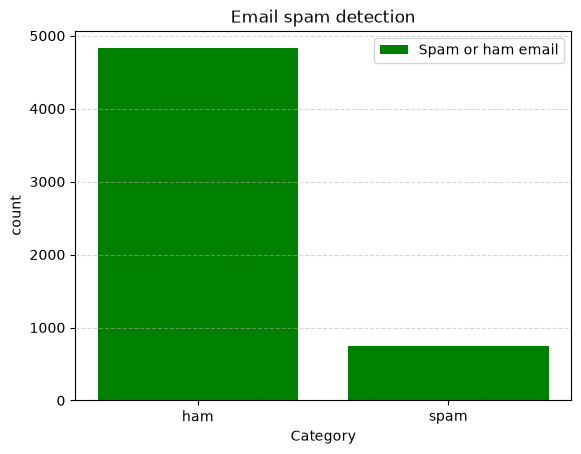

In [7]:
X = df['Category'].unique()
y = [total_ham,total_spam]

plot_barchat(X,y)

In [13]:
ham_dataset = df[df["Category"] == "ham"]
spam_dataset = df[df['Category']=="spam"]
spam_dataset

,Category,Message,Message_length,Word_count
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
5,spam,FreeMsg Hey there darling it's been 3 week's n...,147,32
8,spam,WINNER!! As a valued network customer you have...,157,26
9,spam,Had your mobile 11 months or more? U R entitle...,154,29
11,spam,"SIX chances to win CASH! From 100 to 20,000 po...",136,26
...,...,...,...,...
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...,90,16
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,158,33
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...,160,28
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...,147,28


In [9]:
df["Message_length"]  = df["Message"].str.len()
df["Word_count"] = df["Message"].str.split().str.len()
avg_ham = (df['Category']=="ham").astype(int).mean()
avg_spam = (df['Category']=="spam").astype(int).mean()
ham_word_avg = df[df["Category"] == "ham"]["Word_count"].mean()
spam_word_avg = df[df["Category"] == "spam"]["Word_count"].mean()



In [10]:
def histogram_graph(X,colour='red',titles='Graph',lable='data',):
    plt.figure(figsize=(5,3),dpi=200)
    bins = [x for x in range(20,220,20)]
    plt.hist(X,bins = bins,color=colour,edgecolor='black',label=lable)
    plt.title(titles)
    plt.legend(loc="upper right",fontsize=8)
    plt.show()
    
def boxplot_graph(X,title='Graph',lable='data',xtickels=[1,2]):

    plt.figure(figsize=(5,3),dpi=200)
    plt.style.use("default")
    plt.boxplot(X,label=lable)
    plt.xticks([1,2],xtickels)
    plt.legend(loc="upper right",fontsize=8)
    plt.show()



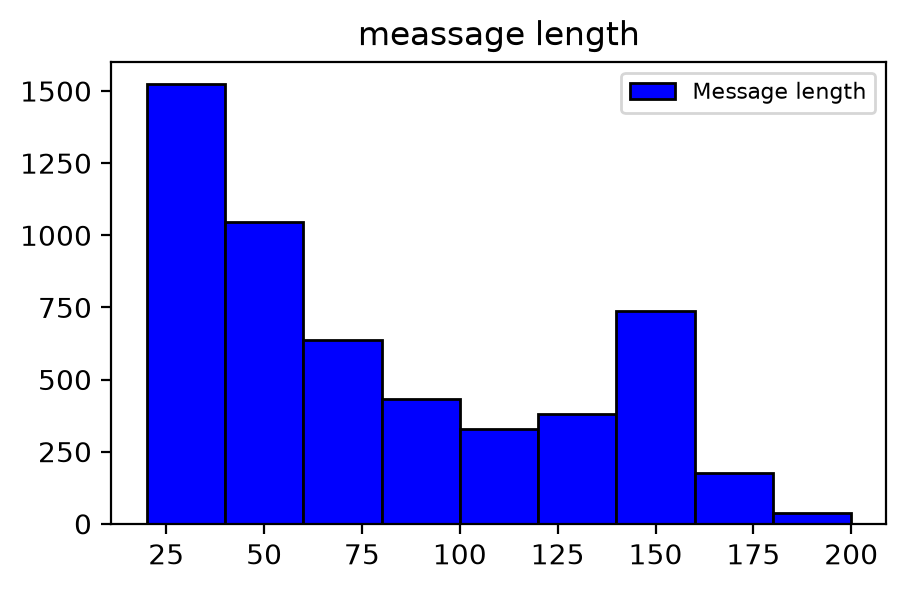

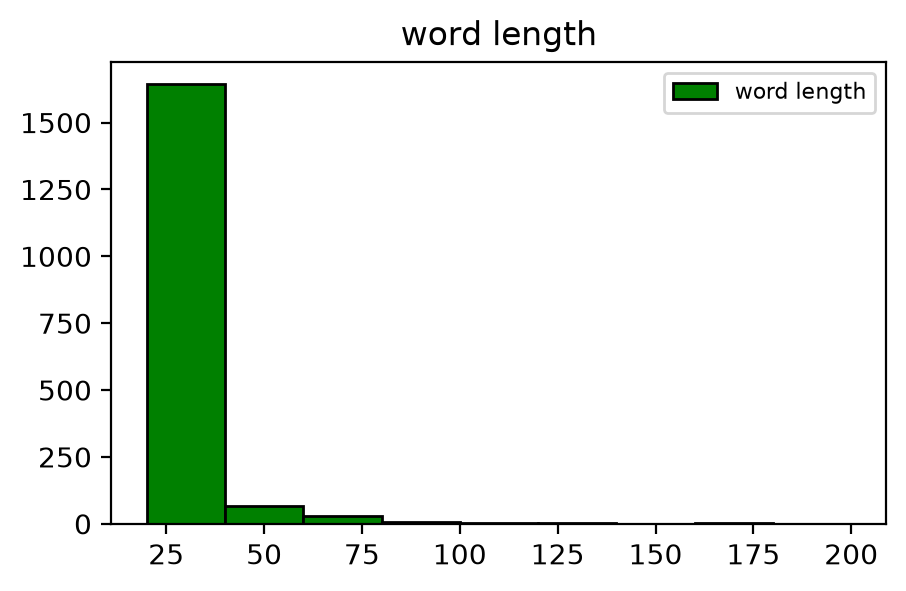

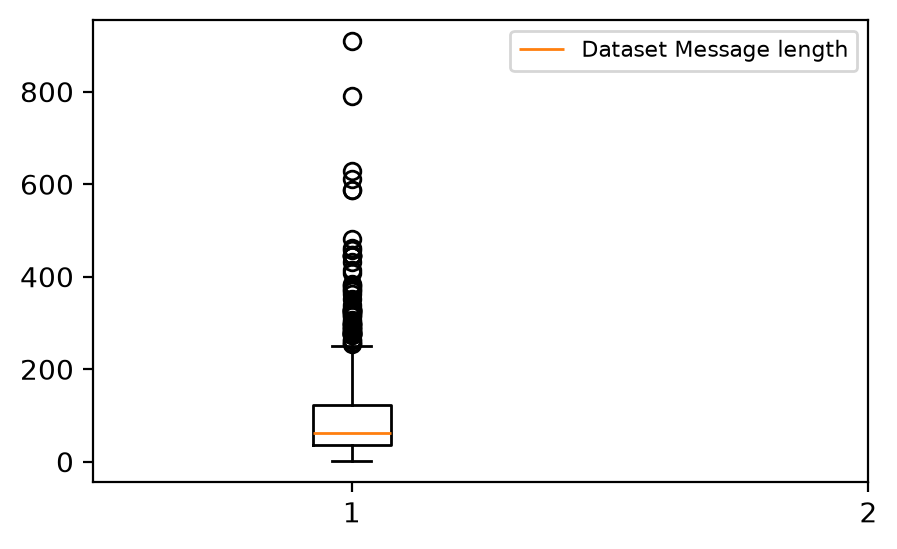

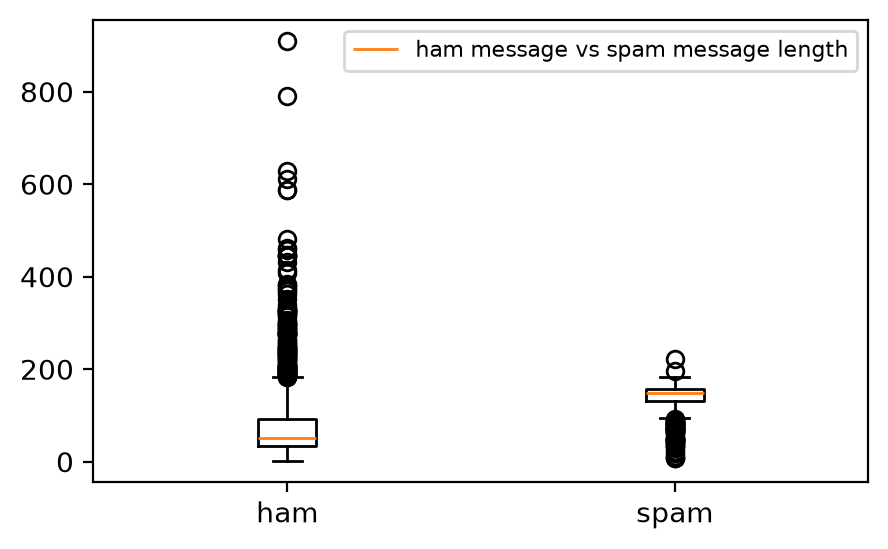

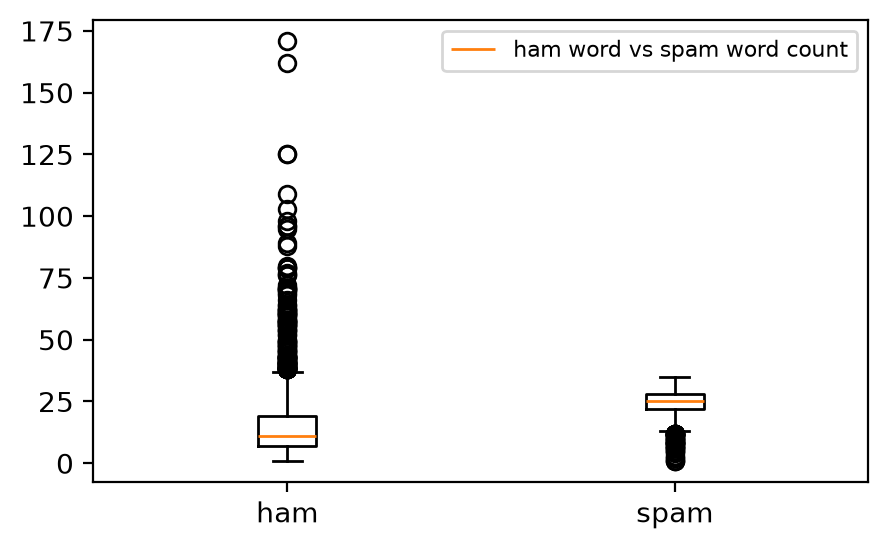

''

In [14]:

histogram_graph(df["Message_length"],"blue","meassage length",lable="Message length")
histogram_graph(df["Word_count"],"Green","word length",lable="word length")
boxplot_graph(df["Message_length"],"Message length",lable="Dataset Message length")
boxplot_graph([ham_dataset['Message_length'],spam_dataset['Message_length']],"message length vs word length",lable='ham message vs spam message length',xtickels=['ham','spam'])
boxplot_graph([ham_dataset['Word_count'],spam_dataset['Word_count']],"message length vs word length",lable='ham word vs spam word count',xtickels=['ham','spam'])

''

NLP preprocessing pipeline.
Text Preprocessing

In [39]:
df['processed_Message'] = df['Message'].apply(preprocess_text)
df['clean_message'] = df['processed_Message'].str.join(" ")
df.columns

Index(['Category', 'Message', 'Message_length', 'Word_count',
       'processed_Message', 'clean_message'],
      dtype='str')

In [40]:

cv = CountVectorizer()

X = cv.fit_transform(df["clean_message"])
print(type(X))
print(X.shape)
print(cv.get_feature_names_out()[:20])


<class 'scipy.sparse._csr.csr_matrix'>
(5572, 8169)
['008704050406' '0089mi' '0121' '01223585236' '01223585334' '0125698789'
 '02' '020603' '0207' '02070836089' '02072069400' '02073162414'
 '02085076972' '020903' '021' '050703' '0578' '06' '060505' '061104']


In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,df['Category'],test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4457, 8169)
(1115, 8169)
(4457,)
(1115,)


In [19]:
naive_model = MultinomialNB()
naive_model.fit(X_train,y_train)
y_pred = naive_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 98.03%


In [20]:
cm = confusion_matrix(y_test,y_pred)

precision = precision_score(y_test,y_pred,pos_label="spam")
recall = recall_score(y_test,y_pred,pos_label="spam")
f1_score = f1_score(y_test,y_pred,pos_label="spam")

print(cm)
print(precision)
print(recall)
print(f1_score)

[[956  10]
 [ 12 137]]
0.9319727891156463
0.9194630872483222
0.9256756756756757


In [ ]:
cd = classification_report(y_test,y_pred)

print(cd)

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.93      0.92      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [44]:
joblib.dump(naive_model,"../models/spam_model.joblib")
joblib.dump(cv,"../models/vectorizer.joblib")

['../models/vectorizer.joblib']